# PB-13 | Hyperparameter Tuning
**Sprint 4 — dp261-g6**

Estrategia:
1. RandomizedSearchCV para exploración amplia
2. GridSearchCV para refinamiento sobre los mejores candidatos
3. Comparación baseline vs tuned
4. Persistencia de modelos tuneados

In [61]:
import os
import sys
import warnings
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    RandomizedSearchCV, GridSearchCV,
    StratifiedKFold, cross_val_score
)
from sklearn.metrics import (
    classification_report, roc_auc_score,
    f1_score, confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from scipy.stats import randint, uniform, loguniform
from sklearn.metrics import recall_score
from sklearn.base import clone

warnings.filterwarnings('ignore')
sys.path.append(os.path.abspath('../'))

RANDOM_STATE = 42
N_JOBS = -1
CV_FOLDS = 5
N_ITER_RANDOM = 15  # iteraciones para RandomizedSearchCV

print('Librerías cargadas correctamente')

Librerías cargadas correctamente


## 1. Carga de datos y modelos baseline

In [52]:
# Datos
df_train = pd.read_csv('../data/processed/train_balanced.csv')
X_train = df_train.drop('y', axis=1)
y_train = df_train['y']

df_test = pd.read_csv('../data/processed/test_original.csv')
X_test = df_test.drop('y', axis=1)
y_test = df_test['y']

# Preprocesador
preproc = joblib.load('../models/preprocessor.pkl')

# Modelos baseline
baseline_names = ['lr', 'dt', 'rf', 'knn']
baselines = {}
for name in baseline_names:
    baselines[name] = joblib.load(f'../models/baseline_{name}.pkl')

## agregado para validar
#print(baselines['lr'].named_steps)
#print(X_train.dtypes.value_counts())
#print(X_train.head(2))
## fin de validacion
print(f'Train: {X_train.shape} | Test: {X_test.shape}')
print(f'Baselines cargados: {list(baselines.keys())}')

Train: (40178, 44) | Test: (5732, 44)
Baselines cargados: ['lr', 'dt', 'rf', 'knn']


## 2. Métricas baseline (referencia)

In [53]:
def eval_model(name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else None
    f1 = f1_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob) if y_prob is not None else None
    return {'model': name, 'f1': round(f1, 4), 'recall': round(recall, 4), 'auc': round(auc, 4) if auc else 'N/A'}

baseline_results = [eval_model(n, m, X_test, y_test) for n, m in baselines.items()]
df_baseline = pd.DataFrame(baseline_results).set_index('model')
print('=== MÉTRICAS BASELINE ===')
df_baseline

=== MÉTRICAS BASELINE ===


,f1,recall,auc
model,,,
lr,0.3922,0.5402,0.7369
dt,0.3590,0.3907,0.6395
rf,0.4371,0.4358,0.7722
knn,0.3624,0.5444,0.7069


## 3. Definición de espacios de búsqueda

In [54]:
cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)

# Espacios para RandomizedSearchCV
random_spaces = {
    'lr': {
        'C': loguniform(1e-3, 1e3),
        'penalty': ['l1', 'l2'],
        'solver': ['liblinear', 'saga']
    },
    'dt': {
        'max_depth': randint(3, 20),
        'min_samples_split': randint(2, 20),
        'min_samples_leaf': randint(1, 10),
        'criterion': ['gini', 'entropy']
    },
    'rf': {
        'n_estimators': randint(50, 300),
        'max_depth': randint(3, 20),
        'min_samples_split': randint(2, 10),
        'max_features': ['sqrt', 'log2']
    },
    'knn': {
        'n_neighbors': randint(3, 30),
        'weights': ['uniform', 'distance'],
        'metric': ['euclidean', 'manhattan']
    }
}

# Modelos base para construir pipelines
base_models = {
    'lr':  LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    'dt':  DecisionTreeClassifier(random_state=RANDOM_STATE),
    'rf':  RandomForestClassifier(random_state=RANDOM_STATE),
    'knn': KNeighborsClassifier()
}

print('Espacios de búsqueda definidos')

Espacios de búsqueda definidos


## 4. RandomizedSearchCV — exploración amplia

In [55]:
random_search_results = {}

for name, model in base_models.items():
    print(f'RandomizedSearch: {name}...')    
    rs = RandomizedSearchCV(
        model,
        param_distributions=random_spaces[name],
        n_iter=N_ITER_RANDOM,
        scoring='recall',
        cv=cv,
        n_jobs=N_JOBS,
        random_state=RANDOM_STATE,
        verbose=0
    )
    rs.fit(X_train, y_train)
    random_search_results[name] = rs
    print(f'  Mejor Recall CV: {rs.best_score_:.4f} | Params: {rs.best_params_}')

print('\nRandomizedSearchCV completado')

RandomizedSearch: lr...
  Mejor Recall CV: 0.7721 | Params: {'C': np.float64(0.5450293694558254), 'penalty': 'l1', 'solver': 'saga'}
RandomizedSearch: dt...
  Mejor Recall CV: 0.8721 | Params: {'criterion': 'gini', 'max_depth': 19, 'min_samples_leaf': 3, 'min_samples_split': 13}
RandomizedSearch: rf...
  Mejor Recall CV: 0.8939 | Params: {'max_depth': 18, 'max_features': 'sqrt', 'min_samples_split': 7, 'n_estimators': 239}
RandomizedSearch: knn...
  Mejor Recall CV: 0.9467 | Params: {'metric': 'euclidean', 'n_neighbors': 6, 'weights': 'distance'}

RandomizedSearchCV completado


## 5. GridSearchCV — refinamiento sobre mejores candidatos

In [63]:
def build_grid_space(name, best_params):
    grid = {}
    
    if name == 'lr':
        c_val = best_params['C']
        grid = {
            'C': [c_val * 0.1, c_val * 0.5, c_val, c_val * 2, c_val * 10],
            'penalty': [best_params['penalty']],
            'solver': [best_params['solver']]
        }
    elif name == 'dt':
        md = best_params['max_depth']
        grid = {
            'max_depth': [max(2, md-2), md, md+2],
            'min_samples_split': [best_params['min_samples_split']],
            'min_samples_leaf': [best_params['min_samples_leaf']],
            'criterion': [best_params['criterion']]
        }
    elif name == 'rf':
        ne = best_params['n_estimators']
        grid = {
            'n_estimators': [max(50, ne-50), ne, ne+50],
            'max_depth': [best_params['max_depth']],
            'min_samples_split': [best_params['min_samples_split']],
            'max_features': [best_params['max_features']]
        }
    elif name == 'knn':
        k = best_params['n_neighbors']
        grid = {
            'n_neighbors': [max(1, k-2), k, k+2],
            'weights': [best_params['weights']],
            'metric': [best_params['metric']]
        }
    return grid


grid_search_results = {}

for name, rs in random_search_results.items():
    print(name, type(rs.best_estimator_))
    print(f'GridSearch: {name}...')
    #se agrega para validar
    print(f'  best_params: {rs.best_params_}')

    grid_space = build_grid_space(name, rs.best_params_)
    
    gs = GridSearchCV(
        clone(rs.best_estimator_),
        param_grid=grid_space,
        scoring='recall',
        cv=cv,
        n_jobs=N_JOBS,
        verbose=0
    )
    gs.fit(X_train, y_train)
    grid_search_results[name] = gs
    print(f'  Mejor Recall CV: {gs.best_score_:.4f} | Params: {gs.best_params_}')

print('\nGridSearchCV completado')

lr <class 'sklearn.linear_model._logistic.LogisticRegression'>
GridSearch: lr...
  best_params: {'C': np.float64(0.5450293694558254), 'penalty': 'l1', 'solver': 'saga'}
  Mejor Recall CV: 0.7721 | Params: {'C': np.float64(0.5450293694558254), 'penalty': 'l1', 'solver': 'saga'}
dt <class 'sklearn.tree._classes.DecisionTreeClassifier'>
GridSearch: dt...
  best_params: {'criterion': 'gini', 'max_depth': 19, 'min_samples_leaf': 3, 'min_samples_split': 13}
  Mejor Recall CV: 0.8741 | Params: {'criterion': 'gini', 'max_depth': 21, 'min_samples_leaf': 3, 'min_samples_split': 13}
rf <class 'sklearn.ensemble._forest.RandomForestClassifier'>
GridSearch: rf...
  best_params: {'max_depth': 18, 'max_features': 'sqrt', 'min_samples_split': 7, 'n_estimators': 239}
  Mejor Recall CV: 0.8948 | Params: {'max_depth': 18, 'max_features': 'sqrt', 'min_samples_split': 7, 'n_estimators': 289}
knn <class 'sklearn.neighbors._classification.KNeighborsClassifier'>
GridSearch: knn...
  best_params: {'metric': 'eu

## 6. Comparación baseline vs tuned

In [64]:
comparison = []

for name in baseline_names:
    # Baseline
    base = baselines[name]
    y_pred_base = base.predict(X_test)
    y_prob_base = base.predict_proba(X_test)[:, 1]
    
    # Tuned
    tuned = grid_search_results[name].best_estimator_
    y_pred_tuned = tuned.predict(X_test)
    y_prob_tuned = tuned.predict_proba(X_test)[:, 1]
    
    comparison.append({
        'model': name,
        'recall_baseline': round(recall_score(y_test, y_pred_base), 4),
        'recall_tuned':    round(recall_score(y_test, y_pred_tuned), 4)
    })

df_comparison = pd.DataFrame(comparison).set_index('model')
df_comparison['delta_recall'] = df_comparison['recall_tuned'] - df_comparison['recall_baseline']

print('=== BASELINE vs TUNED ===')
df_comparison

=== BASELINE vs TUNED ===


,recall_baseline,recall_tuned,delta_recall
model,,,
lr,0.5402,0.5374,-0.0028
dt,0.3907,0.3907,0.0000
rf,0.4358,0.5063,0.0705
knn,0.5444,0.6347,0.0903


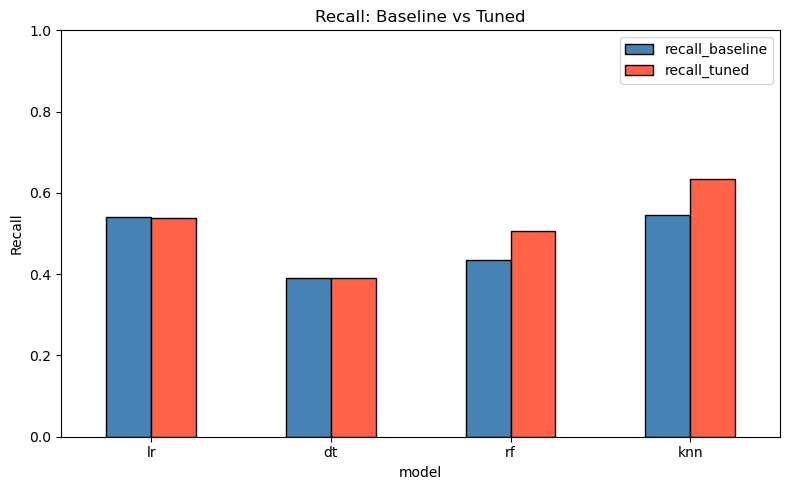

In [65]:
fig, ax1 = plt.subplots(figsize=(8, 5))

df_comparison[['recall_baseline', 'recall_tuned']].plot(
    kind='bar', ax=ax1, color=['steelblue', 'tomato'], edgecolor='black'
)
ax1.set_title('Recall: Baseline vs Tuned')
ax1.set_ylabel('Recall')
ax1.set_ylim(0, 1)
ax1.legend()
ax1.tick_params(axis='x', rotation=0)

plt.tight_layout()
os.makedirs('../reports/figures', exist_ok=True)
plt.savefig('../reports/figures/baseline_vs_tuned.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Persistencia de modelos tuneados

In [66]:
os.makedirs('../models', exist_ok=True)

for name, gs in grid_search_results.items():
    path = f'../models/tuned_{name}.pkl'
    joblib.dump(gs.best_estimator_, path)
    print(f'Guardado: {path}')

print('\nTodos los modelos tuneados guardados.')

Guardado: ../models/tuned_lr.pkl
Guardado: ../models/tuned_dt.pkl
Guardado: ../models/tuned_rf.pkl
Guardado: ../models/tuned_knn.pkl

Todos los modelos tuneados guardados.


## 8. Documentación de mejores hiperparámetros

In [67]:
print('=== MEJORES HIPERPARÁMETROS ENCONTRADOS ===\n')
for name, gs in grid_search_results.items():
    print(f'--- {name.upper()} ---')
    print(f'  Mejor F1 CV:  {gs.best_score_:.4f}')
    for param, val in gs.best_params_.items():
        print(f'  {param}: {val}')
    print()

=== MEJORES HIPERPARÁMETROS ENCONTRADOS ===

--- LR ---
  Mejor F1 CV:  0.7721
  C: 0.5450293694558254
  penalty: l1
  solver: saga

--- DT ---
  Mejor F1 CV:  0.8741
  criterion: gini
  max_depth: 21
  min_samples_leaf: 3
  min_samples_split: 13

--- RF ---
  Mejor F1 CV:  0.8948
  max_depth: 18
  max_features: sqrt
  min_samples_split: 7
  n_estimators: 289

--- KNN ---
  Mejor F1 CV:  0.9477
  metric: euclidean
  n_neighbors: 8
  weights: distance

